In [109]:
import pandas as pd
import numpy as np

In [110]:
matches = pd.read_csv("/content/matches_updated_ipl_upto_2025.csv")

In [111]:
deliveries = pd.read_csv("/content/deliveries_updated_ipl_upto_2025.csv")

In [112]:
deliveries = deliveries.rename(columns={
    "matchId": "match_id",
    "batsman": "striker",
    "batsman_runs": "runs_off_bat",
    "isWide": "wide",
    "isNoBall": "noball",
    "Byes": "byes",
    "LegByes": "legbyes",
    "Penalty": "penalty",
    "dismissal_kind": "wicket_type"
})

In [113]:
matches = matches.rename(columns={
    "matchId": "match_id"
})

In [114]:
deliveries["date"] = pd.to_datetime(deliveries["date"])
matches["date"] = pd.to_datetime(matches["date"])

In [115]:
num_cols = [
    "runs_off_bat", "extras", "wide", "noball",
    "byes", "legbyes", "penalty"
]
deliveries[num_cols] = deliveries[num_cols].fillna(0).astype(int)

In [116]:
deliveries.duplicated(
    subset=["match_id", "inning", "over", "ball"]
).sum()

deliveries = deliveries.drop_duplicates(
    subset=["match_id", "inning", "over", "ball"],
    keep="first"
)

In [117]:
deliveries = deliveries.drop(
    columns=["penalty", "byes", "legbyes", "date"]
)

In [118]:
matches = matches.drop(columns=[
    "winner", "outcome", "winner_runs", "winner_wickets",
    "player_of_match", "umpire1", "umpire2", "tv_umpire",
    "reserve_umpire", "match_referee", "event", "method",
    "toss_decision", "toss_winner", "date1", "date2"
])

In [119]:
matches_keep = matches[
    ["match_id", "season", "venue", "city",
     "team1", "team2", "neutralvenue"]
]

In [120]:
df = deliveries.merge(
    matches_keep,
    on="match_id",
    how="left"
)

In [121]:
# df["opponent_team"] = df.apply(
#     lambda x: x["team2"]
#     if x["batting_team"] == x["team1"]
#     else x["team1"],
#     axis=1
# )

In [122]:
df = df.drop(columns=["team1", "team2"])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278170 entries, 0 to 278169
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          278170 non-null  int64  
 1   inning            278170 non-null  int64  
 2   over_ball         278170 non-null  float64
 3   over              278170 non-null  int64  
 4   ball              278170 non-null  int64  
 5   batting_team      278170 non-null  object 
 6   bowling_team      278170 non-null  object 
 7   striker           278170 non-null  object 
 8   non_striker       278170 non-null  object 
 9   bowler            278170 non-null  object 
 10  runs_off_bat      278170 non-null  int64  
 11  extras            278170 non-null  int64  
 12  wide              278170 non-null  int64  
 13  noball            278170 non-null  int64  
 14  wicket_type       13822 non-null   object 
 15  player_dismissed  13822 non-null   object 
 16  season            27

In [124]:
df.isna().sum()

,0
match_id,0
inning,0
over_ball,0
over,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0
bowler,0


In [125]:
df["is_wicket"] = df["player_dismissed"].notna().astype(int)

In [126]:
df["city"] = df["city"].fillna("Unknown")
df["neutralvenue"] = df["neutralvenue"].fillna(0).astype(int)

In [127]:
bowler_wicket_types = [
    "bowled", "caught", "lbw", "stumped", "caught and bowled", "hit wicket"
]

df["is_bowler_wicket"] = (
    df["wicket_type"].isin(bowler_wicket_types)
).astype(int)

In [128]:
# Select object (string) columns
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    print(f"\nColumn: {col}")
    print(f"Unique count: {df[col].nunique()}")
    print("Sample unique values:")
    print(df[col].dropna().unique()[:20])  # show first 20


Column: batting_team
Unique count: 19
Sample unique values:
['Kolkata Knight Riders' 'Royal Challengers Bangalore'
 'Chennai Super Kings' 'Kings XI Punjab' 'Rajasthan Royals'
 'Delhi Daredevils' 'Mumbai Indians' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Sunrisers Hyderabad'
 'Rising Pune Supergiants' 'Gujarat Lions' 'Rising Pune Supergiant'
 'Delhi Capitals' 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']

Column: bowling_team
Unique count: 19
Sample unique values:
['Royal Challengers Bangalore' 'Kolkata Knight Riders' 'Kings XI Punjab'
 'Chennai Super Kings' 'Delhi Daredevils' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Delhi Capitals' 'Punjab Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Royal Challengers Bengaluru']

Column: striker
Unique count: 704
Sample unique values:
['SC Ganguly

<Axes: xlabel='runs_off_bat'>

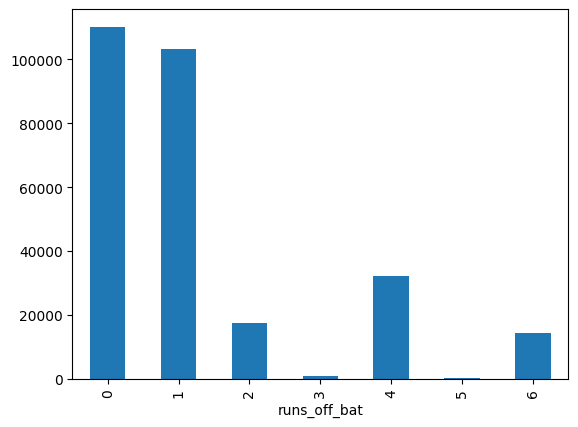

In [133]:
df["runs_off_bat"].value_counts().sort_index().plot(kind="bar")

In [134]:
df["is_wicket"] = df["player_dismissed"].notna().astype(int)

df["is_wicket"].value_counts(normalize=True)

df["wicket_type"].value_counts()

,count
wicket_type,
caught,8664
bowled,2345
run out,1153
lbw,853
caught and bowled,388
stumped,376
hit wicket,18
retired hurt,17
retired out,5


In [137]:
df.groupby("venue")["runs_off_bat"].mean().sort_values(ascending=False).sample(10)

,runs_off_bat
venue,
"Vidarbha Cricket Association Stadium, Jamtha",1.103914
Feroz Shah Kotla,1.254409
Eden Gardens,1.247665
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",1.477645
Arun Jaitley Stadium,1.296484
"Himachal Pradesh Cricket Association Stadium, Dharamsala",1.536210
M Chinnaswamy Stadium,1.283663
"Sawai Mansingh Stadium, Jaipur",1.442384
"Punjab Cricket Association IS Bindra Stadium, Mohali",1.327117


In [136]:
df.groupby("venue")["is_bowler_wicket"].mean().sort_values(ascending=False).head(10)

,is_bowler_wicket
venue,
"Vidarbha Cricket Association Stadium, Jamtha",0.058030
"Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur",0.057958
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",0.057113
Newlands,0.053281
"Maharashtra Cricket Association Stadium, Pune",0.051282
"Himachal Pradesh Cricket Association Stadium, Dharamsala",0.050847
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,0.050708
"MA Chidambaram Stadium, Chepauk, Chennai",0.049885
Dr DY Patil Sports Academy,0.049837


In [140]:
player_matches = df.groupby("striker")["match_id"].nunique()

player_matches.describe()

,match_id
count,704.000000
mean,25.052557
std,40.288488
min,1.000000
25%,3.000000
50%,8.500000
75%,27.000000
max,266.000000


<Axes: >

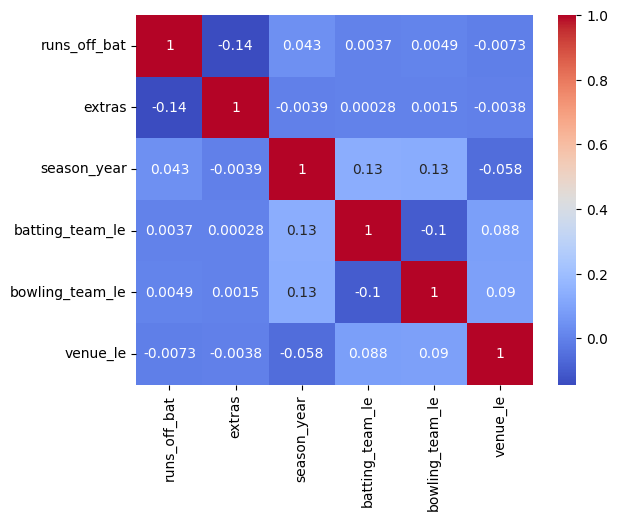

In [141]:
eda_cols = [
    "runs_off_bat",
    "extras",
    "season_year",
    "batting_team_le",
    "bowling_team_le",
    "venue_le"
]

sns.heatmap(eda_df[eda_cols].corr(), annot=True, cmap="coolwarm")


In [143]:
team_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

for col in ["batting_team", "bowling_team"]:
    df[col] = df[col].replace(team_map)